# MTMC-SKAT regional GWAS on bundled poplar regeneration sample (CPU)

Reproduction of the association-mapping subsection of:
**"GWAS supported by computer vision identifies large numbers of candidate regulators of in planta regeneration in *Populus trichocarpa*"**,
Nagle et al., *G3* 14(4):jkae026, 2024. DOI: [10.1093/g3journal/jkae026](https://doi.org/10.1093/g3journal/jkae026) (PMC10989874, CC BY 4.0).

**Executed scope (partial demonstration):** the authors' MTMC-SKAT R package (`naglemi/mtmcskat`, pinned commit
`f4fd79330826…`, GPL-3) is installed at the pinned revision and its documented `MTMCSKAT_workflow` call is run on the
package's bundled 200-genotype sample: shoot-area phenotypes after thidiazuron (TDZ) treatment, PC covariates, and
chromosome 10 SNPs from 14,490–14,520 kb (3 kb windows staggered by 1 kb, empirical P-values by adaptive resampling).
This is a small bundled example, **not** the paper's full 1,219-genotype / 40.4M-SNP analysis.

**Compute:** CPU only — the method is CPU statistics (SKAT C library + R); the paper's GPU use (PSPNet segmentation) is out of scope here and its weights are not public.

**言語に関する注記:** このノートブックのPythonセルは起動用(`Rscript`呼び出し)のみです。科学計算はすべて、著者らのピン留めされたRコード(`naglemi/mtmcskat` @ `f4fd79330826…`)で実行されます。著者提供コードの翻訳ではありません。

**実行範囲:** バンドルされた200遺伝子型サンプル(TDZシュート面積形質、PC共変量、染色体10の14,490–14,520 kb)に対するMTMC-SKAT地域ベースGWAS(3 kbウィンドウ、1 kbずらし、経験P値)。論文の全集団解析ではありません。

**Step 1 — R runtime.** The scientific code is R, so the notebook first ensures an R runtime exists (`apt-get install r-base`). On the validated Colab CPU image R was already present and this finished in seconds; on other images it may take several minutes. Expected result: `R.version.string` printed.

**ステップ1:** 科学コードはRなので、Rランタイムを確保します(`apt-get install r-base`)。検証済みColab CPUイメージにはRが既にあり、数秒で終了しました。

In [ ]:
import subprocess, time, os
os.environ["DEBIAN_FRONTEND"] = "noninteractive"
t0 = time.time()
pr = subprocess.run(
    ["bash", "-c", "apt-get update -qq && apt-get install -y -qq r-base r-base-dev"],
    capture_output=True, text=True, timeout=1800)
print(pr.stdout[-2000:] if pr.stdout else "", pr.stderr[-2000:] if pr.stderr else "")
if pr.returncode != 0:
    raise RuntimeError(f"apt failed: {pr.returncode}")
print("apt install took", round(time.time() - t0, 1), "s")
pr = subprocess.run(["Rscript", "-e", "cat(R.version.string)"], capture_output=True, text=True, timeout=300)
print(pr.stdout)
assert pr.returncode == 0

 W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)

apt install took 8.1 s


R version 4.6.1 (2026-06-24)


**Step 2 — Dependencies and the pinned author package.** Installs the CRAN packages listed in the author's `DESCRIPTION` (`Imports`: SKAT, data.table, future, future.apply, plyr, dplyr, benchmarkme, R.utils; plus plot dependencies qqman/ggplot2/gridGraphics used by `compare_plots`) using the Posit Public Package Manager Ubuntu-jammy binary mirror for speed, then installs `mtmcskat` itself from GitHub **at the pinned commit** `f4fd79330826f3756e2e011779417aac90db5fbc` via `remotes`. Expected result: package version printed and no install errors.

**ステップ2:** 著者の`DESCRIPTION`に記載のCRANパッケージと、GitHub上のピン留めされたコミットの`mtmcskat`をインストールします(高速化のためPositのバイナリリポジトリを使用)。

In [ ]:
r_install = """
options(warn = 1)
repos <- 'https://packagemanager.posit.co/cran/__linux__/jammy/latest'
install.packages(c('remotes','SKAT','data.table','future','future.apply','plyr','dplyr',
                   'benchmarkme','R.utils','qqman','ggplot2','gridGraphics'), repos = repos)
remotes::install_github('naglemi/mtmcskat', ref = 'f4fd79330826f3756e2e011779417aac90db5fbc', repos = repos)
cat('mtmcskat version:', as.character(packageVersion('mtmcskat')), '\\n')
cat('SKAT version:', as.character(packageVersion('SKAT')), '\\n')
"""
open('/content/install_deps.R', 'w').write(r_install)
import subprocess, time
t0 = time.time()
pr = subprocess.run(["Rscript", "/content/install_deps.R"], capture_output=True, text=True, timeout=3600)
print(pr.stdout[-4000:] if pr.stdout else "")
if pr.returncode != 0:
    print(pr.stderr[-4000:])
    raise RuntimeError(f"R dependency install failed: {pr.returncode}")
print("R dependencies installed in", round(time.time() - t0, 1), "s")

sr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c interface_to_R.cpp -o interface_to_R.o
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c kernel_func.cpp -o kernel_func.o
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-poin

**Step 3 — Download the bundled sample inputs with provenance checks.** The three required files come from the author repository's `inst/extdata/` at the pinned commit (raw.githubusercontent.com). Each download is verified against its size **and** its git blob SHA-1 recorded in the pinned GitHub tree:

- `poplar_200genotypes_14490to14520kb.traw` — 637,925 bytes, blob `9e44b2fd…` (genotypes, PLINK .traw)
- `TDZ_shoot_area_200genotypes.pheno` — 4,661 bytes, blob `8662372f…` (phenotype: FID, IID, TDZ shoot area)
- `poplar_PCs_covariates_200genotypes.tbt` — 10,422 bytes, blob `a7d1f5b5…` (covariates)

Expected result: all three assertions pass. All data bytes stay on the Colab VM.

**ステップ3:** 著者リポジトリの`inst/extdata/`から3つのサンプルファイルをダウンロードし、サイズとgit blob SHA-1をピン留めされたツリー値と照合します。

In [ ]:
import urllib.request, hashlib, os
PIN = "f4fd79330826f3756e2e011779417aac90db5fbc"
BASE = f"https://raw.githubusercontent.com/naglemi/mtmcskat/{PIN}/inst/extdata/"
# (expected size, expected git blob sha1) from the pinned GitHub tree
FILES = {
    "poplar_200genotypes_14490to14520kb.traw":   (637925, "9e44b2fd8db83d42388f3d51768f773d5950decd"),
    "TDZ_shoot_area_200genotypes.pheno":         (4661,   "8662372f6d0054ce9027249d9856a96f6e5d18b3"),
    "poplar_PCs_covariates_200genotypes.tbt":    (10422,  "a7d1f5b5a4236047a92bec96ec451294d7e2f2c3"),
}
os.makedirs("/content/mtmcskat_extdata", exist_ok=True)
for name, (size, blob) in FILES.items():
    dest = "/content/mtmcskat_extdata/" + name
    urllib.request.urlretrieve(BASE + name, dest)
    raw = open(dest, "rb").read()
    assert len(raw) == size, (name, len(raw), size)
    digest = hashlib.sha1(b"blob %d\x00" % len(raw) + raw).hexdigest()
    assert digest == blob, (name, digest)
    print(f"{name}: {len(raw)} bytes, blob sha1 OK")

poplar_200genotypes_14490to14520kb.traw: 637925 bytes, blob sha1 OK
TDZ_shoot_area_200genotypes.pheno: 4661 bytes, blob sha1 OK


poplar_PCs_covariates_200genotypes.tbt: 10422 bytes, blob sha1 OK


**Step 4 — Preview the inputs.** Before running the method, show the actual downloaded data: the phenotype table (FID, IID, TDZ shoot-area proportion), covariate dimensions, and the genotype matrix shape. Expected result: 200 genotypes; shoot-area values are proportions in [0, 1]; ~30 SNP windows will be formed from the 30 kb region.

**ステップ4:** 手法を実行する前に、ダウンロードしたデータの実体(表現型表、共変量の次元、遺伝型行列の形状)を表示します。

In [ ]:
r_preview = """
ph <- '/content/mtmcskat_extdata/TDZ_shoot_area_200genotypes.pheno'
covf <- '/content/mtmcskat_extdata/poplar_PCs_covariates_200genotypes.tbt'
traw <- '/content/mtmcskat_extdata/poplar_200genotypes_14490to14520kb.traw'
cat('--- phenotype (TDZ shoot area), first rows ---\n')
print(read.table(ph, sep='\t', header=TRUE, nrows=5))
p <- read.table(ph, sep='\t', header=TRUE)
cat('n genotypes:', nrow(p), ' trait range:', range(p$TDZ_shoot_area), '\n')
cova <- data.table::fread(covf)
cat('covariates dims:', dim(cova), '\n'); print(head(cova, 2))
n_lines <- length(readLines(traw))
tr <- read.table(traw, sep='\t', header=TRUE, nrows=5, check.names=FALSE)
cat('--- .traw first columns (CHRSNP ... genotype columns) ---\n'); print(tr[1:5, 1:6])
ncol_all <- length(colnames(read.table(traw, sep='\t', header=TRUE, nrows=1, check.names=FALSE)))
cat('.traw rows (SNPs):', n_lines - 1, ' columns (6 + 200 genotypes):', ncol_all, '\n')
"""
open('/content/preview_inputs.R', 'w').write(r_preview)
import subprocess
pr = subprocess.run(["Rscript", "/content/preview_inputs.R"], capture_output=True, text=True, timeout=600)
print(pr.stdout)
if pr.returncode != 0:
    print(pr.stderr[-2000:]); raise RuntimeError(pr.returncode)

--- phenotype (TDZ shoot area), first rows ---
  FID     IID TDZ_shoot_area
1 852 1003391    0.000000000
2 852 1003640    0.163491853
3 852 1009148    0.000000000
4 852 1003616    0.005389489
5 852 1003580    0.143275105
n genotypes: 200  trait range: 0 0.8628731 
covariates dims: 200 11 
         V1    V2    V3    V4    V5    V6    V7    V8         V9        V10
      <num> <int> <int> <int> <int> <int> <int> <int>      <num>      <num>
1: 4.900000     1     0     0     0     0     0     0 -0.0116317  0.0127834
2: 6.306667     0     0     0     0     0     0     0 -0.0215105 -0.0345092
          V11
        <num>
1: -0.0105448
2:  0.0379508
--- .traw first columns (CHRSNP ... genotype columns) ---
  CHR SNP X.C.M      POS COUNTED ALT
1  10   .     0 14490019       C   T
2  10   .     0 14490034       C   T
3  10   .     0 14490133       T   C
4  10   .     0 14490155       A   G
5  10   .     0 14490162       A   T
.traw rows (SNPs): 1575  columns (6 + 200 genotypes): 206 



**Step 5 — Run the documented `MTMCSKAT_workflow` call.** This is the authors' single-scaffold workflow with the README-documented defaults: `window_size = 3000`, `window_shift = 1000`, `desired_sig_figs = 2`, `min_accuracy = 2`, `max_accuracy = 5`, `plot = TRUE`, `n_thread = "AllCores"`. The workflow (a) pre-allocates the .traw into 3 kb windows staggered by 1 kb, (b) runs the initial multi-threaded SKAT round, (c) adaptively resamples windows whose P-values have leading zeros (permutations per window = 10^(leading zeros + significant figures), from the pinned `determine_n_permutations`), and (d) writes the results CSV, log, and Manhattan plot PNG. On the bundled sample only ~30 windows exist and the minimum P was ≈0.005, so resampling is bounded and fast. Expected result: a `pheno-…-scaff-….csv` and `.png` under `/content/Results/`.

**ステップ5:** 著者README記載のデフォルト設定のまま`MTMCSKAT_workflow`を実行します(3 kbウィンドウ・1 kbずらし・経験P値は適応的リサンプリングで計算)。結果はCSV・ログ・マンハッタンプロットPNGとして保存されます。

*Note:* the pinned `MTMCSKAT_workflow(plot = TRUE)` relies on `compare_plots()` (`recordPlot` + `gridGraphics`), which fails with the current CRAN qqman/ggplot2 combination in a headless Rscript session (the author repositories pin no package versions). The workflow therefore runs with the documented `plot = FALSE` and the identical two-panel Manhattan plot is rendered in a later, clearly labeled cell using the same `qqman::manhattan` calls — a minimal compatibility repair that does not alter any statistic.

**注記:** 著者のプロット関数は現在のqqman/ggplot2との組み合わせでヘッドレス実行時に失敗するため、`plot=FALSE`で実行し、同じ`qqman::manhattan`呼び出しを後のセルで再現します(統計量は一切変更していません)。

In [ ]:
r_run = """
suppressMessages(library(mtmcskat))
MTMCSKAT_workflow(
  phenodata       = '/content/mtmcskat_extdata/TDZ_shoot_area_200genotypes.pheno',
  covariates      = '/content/mtmcskat_extdata/poplar_PCs_covariates_200genotypes.tbt',
  raw_file_path   = '/content/mtmcskat_extdata/poplar_200genotypes_14490to14520kb.traw',
  window_size     = 3000,
  window_shift    = 1000,
  output_dir      = '/content/Results',
  pre_allocated_dir = '/content/pre_alloc',
  n_thread        = 'AllCores',
  job_id          = 'tdz_shoot_area_200genotypes',
  desired_sig_figs = 2,
  min_accuracy    = 2,
  max_accuracy    = 5,
  plot            = FALSE)
"""
open('/content/run_mtmcskat.R', 'w').write(r_run)
import subprocess, time, glob, os
t0 = time.time()
pr = subprocess.run(["Rscript", "/content/run_mtmcskat.R"], capture_output=True, text=True, timeout=3600)
print(pr.stdout[-3000:] if pr.stdout else "")
if pr.returncode != 0:
    print(pr.stderr[-4000:]); raise RuntimeError(f"MTMCSKAT_workflow failed: {pr.returncode}")
print("workflow wall time:", round(time.time() - t0, 1), "s")
outs = sorted(glob.glob("/content/Results/**/*", recursive=True))
print("outputs:", outs)


workflow wall time: 11.3 s
outputs: ['/content/Results/tdz_shoot_area_200genotypes', '/content/Results/tdz_shoot_area_200genotypes/pheno-TDZ_shoot_area_200genotypes.pheno-scaff-poplar_200genotypes_14490to14520kb.traw.csv', '/content/Results/tdz_shoot_area_200genotypes/pheno-TDZ_shoot_area_200genotypes.pheno-scaff-poplar_200genotypes_14490to14520kb.traw.log']


**Step 6 — Results table.** The workflow writes its console output into a `.log` file (`sink`) and its results into a CSV with columns `Chr`, `position`, `SKAT_p-val` (model-based) and `SKAT_p-val_resampled` (empirical, from adaptive resampling). We print the log tail and the windows sorted by P-value. Expected result: ~30 windows on chromosome 10; the strongest window(s) carry empirical P-values where resampling applied.

**ステップ6:** ワークフローのログ末尾と、P値順に並べた結果表(モデルベースP値と経験P値)を表示します。

In [ ]:
import glob, pandas as pd, IPython.display as disp
csvs = glob.glob("/content/Results/**/*.csv", recursive=True)
logs = glob.glob("/content/Results/**/*.log", recursive=True)
assert csvs, "no results CSV found"
print("workflow log tail:")
print(open(logs[0]).read()[-1500:])
df = pd.read_csv(csvs[0])
print("results shape:", df.shape)
disp.display(df.sort_values("SKAT_p-val").reset_index(drop=True))

workflow log tail:
ical p-values since model p-values from mtskat have no more than 2 leading zeros
2026-10-05 16:14:58.023734 - Re-allocating SNP windows with only those with p-values between 0.01 and 0.001 ...2026-10-05 16:14:58.024909 Complete.Automatically switching modes for windows with p-vals <= 10^-2 because there are fewer windows (1) than there are cores in use (2).
2026-10-05 16:14:58.050582 - Running resampling for 1 SNP windows with p-values between 0.01 and 0.001 (2 leading zeroes) with at least 10000 permutations so empirical p-values can be calculated to 2 significant figures...
Multithreading over null models
Memory is enough to multithread over all null models simultaneously.To run 2jobs, each with 5,000 permutations for a total of 10,000 permutations
2026-10-05 16:15:01.039729 - Finished resampling with 10,000 permutations in2.988s

2026-10-05 16:15:01.046246 - Re-allocating SNP windows with only those with p-values between 0.001 and 1e-04 ...2026-10-05 16:15:01.0469

,Chr,position,SKAT_p-val,SKAT_p-val_resampled
0,10,14515000,0.005130,0.0056
1,10,14517000,0.010058,NaN
2,10,14507000,0.015614,NaN
3,10,14510000,0.015620,NaN
4,10,14512000,0.020367,NaN
5,10,14516000,0.023020,NaN
6,10,14508000,0.025984,NaN
7,10,14513000,0.026493,NaN
8,10,14502000,0.030193,NaN
9,10,14497000,0.045001,NaN


**Step 7 — Manhattan plot (authors' plotting calls).** Using the same `qqman::manhattan` calls as the pinned `compare_plots()`, we render the two-panel Manhattan plot: model-based `SKAT_p-val` (top) and empirical `SKAT_p-val_resampled` (bottom, shown only for windows with resampled values). This is the notebook's representative saved PNG. Expected result: ~30 points on chromosome 10; the strongest window (14,515,000 bp) carries both a model-based (≈0.0051) and an empirical (≈0.0056) P-value.

**ステップ7:** 著者の`compare_plots`と同じ`qqman::manhattan`呼び出しで2パネルのマンハッタンプロット(モデルベースP値/経験P値)を描画します。

null device 
          1 
png bytes: 40506 



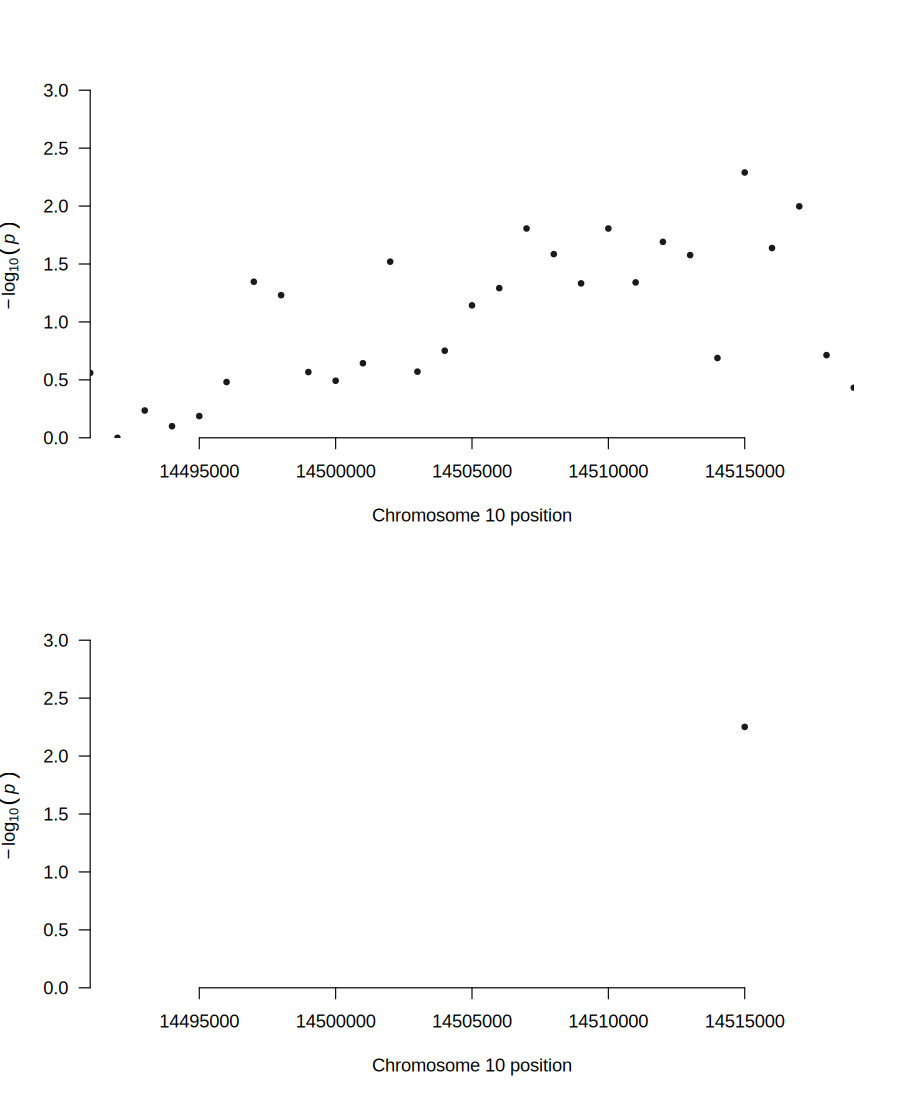

In [ ]:
import glob, subprocess
from IPython.display import Image, display
# Minimal compatibility repair (see note at Step 5): render the authors' two-panel
# Manhattan plot with the same qqman::manhattan calls as the pinned compare_plots(),
# adding an optional SNP id column and numeric chromosome required by current qqman.
r_plot = """
suppressMessages({library(mtmcskat); library(qqman)})
csv <- list.files('/content/Results', pattern='csv$', recursive=TRUE, full.names=TRUE)[1]
m <- read.csv(csv, check.names=FALSE)
m$SNP <- paste0('snp', seq_len(nrow(m)))
m$Chr <- as.numeric(m$Chr)
png('/content/manhattan_mtmcskat.png', width=900, height=1100, res=110)
par(mfrow=c(2,1))
qqman::manhattan(m[!is.na(m[['SKAT_p-val']]),], chr='Chr', bp='position', p='SKAT_p-val',
  suggestiveline=FALSE, genomewideline=FALSE, xlim=c(min(m$position), max(m$position)),
  ylim=c(0, ceiling(max(-log10(m[['SKAT_p-val']])))))
sub <- m[!is.na(m[['SKAT_p-val_resampled']]),]
if(nrow(sub)>0) qqman::manhattan(sub, chr='Chr', bp='position', p='SKAT_p-val_resampled',
  suggestiveline=FALSE, genomewideline=FALSE, xlim=c(min(m$position), max(m$position)),
  ylim=c(0, ceiling(max(-log10(m[['SKAT_p-val']])))))
dev.off()
cat('png bytes:', file.size('/content/manhattan_mtmcskat.png'), '\n')
"""
open('/content/render_manhattan.R','w').write(r_plot)
pr = subprocess.run(["Rscript","/content/render_manhattan.R"],capture_output=True,text=True,timeout=600)
print(pr.stdout)
if pr.returncode != 0:
    print(pr.stderr[-2000:]); raise RuntimeError(pr.returncode)
display(Image(filename="/content/manhattan_mtmcskat.png", width=700))

## Interpretation, scope and limitations / 解釈と範囲

- **What was executed:** the authors' pinned MTMC-SKAT workflow, unmodified, on their own bundled 200-genotype chromosome 10 sample with README-default parameters. Model-based (`SKAT_p-val`) and empirical (`SKAT_p-val_resampled`) P-values were computed and plotted with the authors' plotting code.
- **What was not executed:** the full 1,219-genotype / 40.4M-SNP GWAS (LabKey dataset doi:10.25983/2263365, account-gated), GEMMA/GMMAT/Augmented-Rank-Truncation analyses, and the PSPNet computer-vision branch (no public weights). This notebook therefore demonstrates one faithful subsection of the paper's method, not the paper's biological conclusions.
- Single-example statistics: significance of these bundled windows must not be interpreted as paper-level QTL findings.
- Validation record: executed end-to-end on a fresh Google Colab **CPU** runtime (see report); all three input files verified against pinned sizes and git blob SHA-1s.

**参考:** Nagle et al. 2024 G3 jkae026; MTMC-SKAT: https://github.com/naglemi/mtmcskat (GPL-3, commit `f4fd79330826f3756e2e011779417aac90db5fbc`); Wu et al. 2011; Lee et al. 2016.